# Telecom Customer Churn Prediction

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from datetime import datetime
from scipy.stats import loguniform

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_squared_error, mean_absolute_error,f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
#import  dataset
file_path = "../data/data.csv"
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preprocessing Part 1

In [3]:
# Checking the shape of dataset
df.shape

(7043, 21)

In [4]:
# removed unused column
df.drop('customerID', axis=1, inplace=True)

In [5]:
# Check duplicate
df.duplicated().sum()

np.int64(22)

In [6]:
# Remove duplicate
df.drop_duplicates(inplace=True)

In [7]:
# check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [8]:
# change TotalCharges data type to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
# check missing values
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# delete missing values
df.dropna(inplace=True)

In [11]:
# checking number of unique value of each column
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [12]:
#checking the unique values in each column
cols = df.columns
for i in cols:
    print(i, df[i].unique(), '\n')

gender ['Female' 'Male'] 

SeniorCitizen [0 1] 

Partner ['Yes' 'No'] 

Dependents ['No' 'Yes'] 

tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] 

PhoneService ['No' 'Yes'] 

MultipleLines ['No phone service' 'No' 'Yes'] 

InternetService ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity ['No' 'Yes' 'No internet service'] 

OnlineBackup ['Yes' 'No' 'No internet service'] 

DeviceProtection ['No' 'Yes' 'No internet service'] 

TechSupport ['No' 'Yes' 'No internet service'] 

StreamingTV ['No' 'Yes' 'No internet service'] 

StreamingMovies ['No' 'Yes' 'No internet service'] 

Contract ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling ['Yes' 'No'] 

PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 

MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


# Exploratory Data Analysis
In the exploratory data analysis, I will be visualizing the data to get a better understanding of the data and to see if there are any trends or pattern in the data. First I will begin with looking at the distribution of the data and then I will look at the relationship between the independent variables and the target variable.

### Customer Demographics

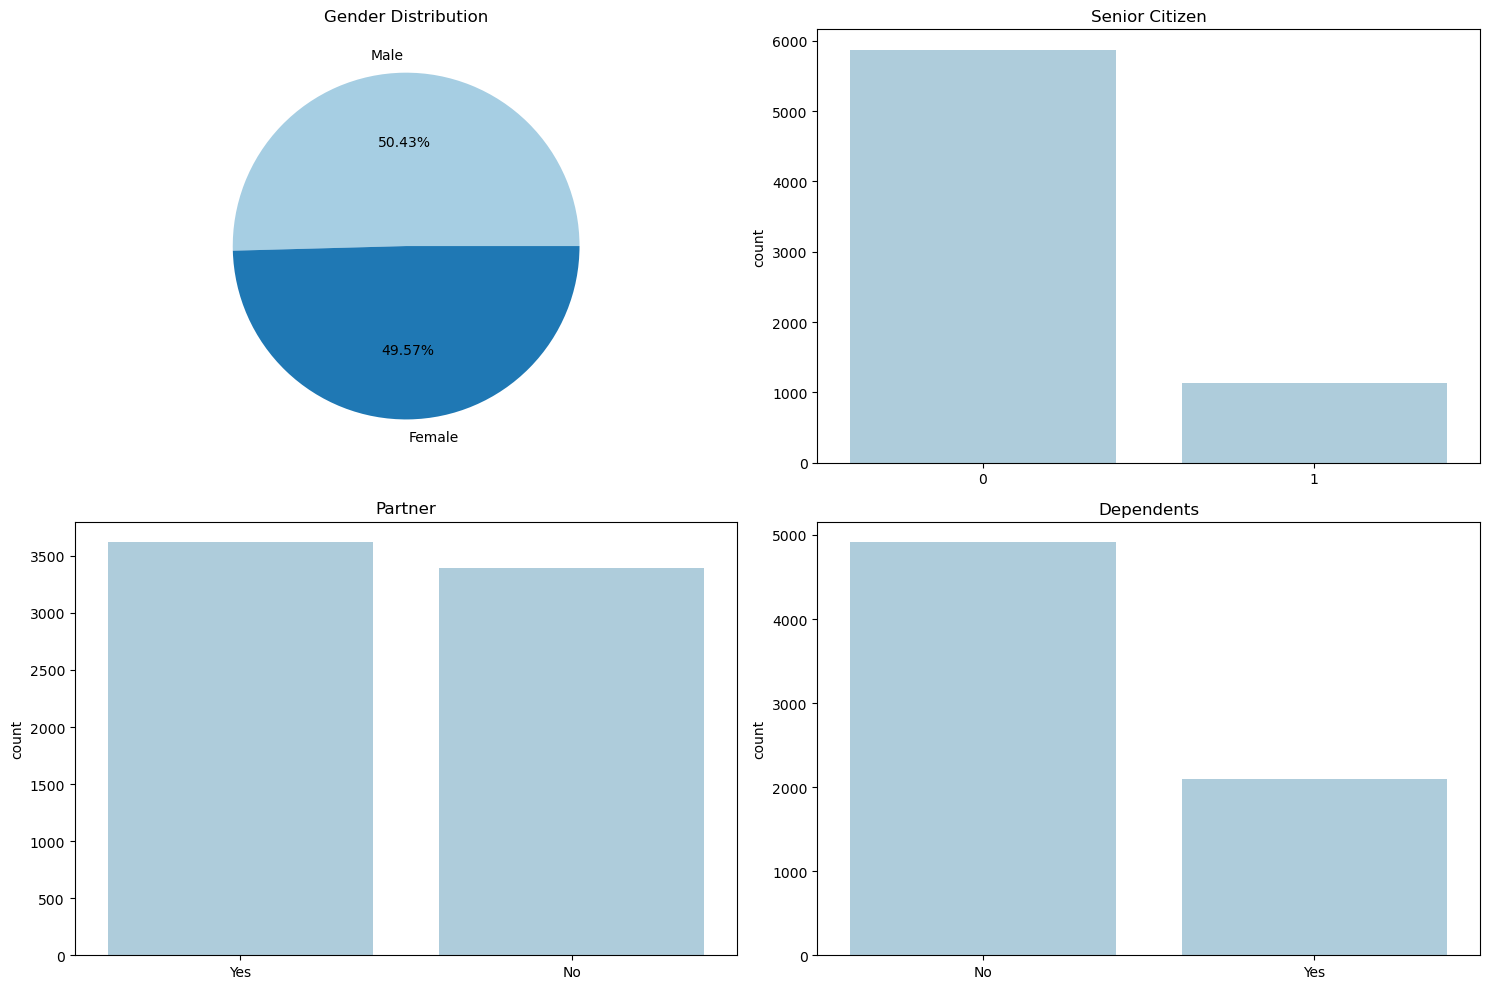

In [14]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#Gender Distribution
ax[0,0].pie(df['gender'].value_counts(), labels  = ['Male', 'Female'], autopct = '%1.2f%%')
ax[0,0].set_title('Gender Distribution')

#Senior Citizen Distribution
sns.barplot(y = df['SeniorCitizen'].value_counts(), x = df['SeniorCitizen'].unique(), ax=ax[0,1]).set_title('Senior Citizen')

#Partner Distribution
sns.barplot(y = df['Partner'].value_counts(), x = df['Partner'].unique(), ax=ax[1,0]).set_title('Partner')

#Dependents Distribution
sns.barplot(y = df['Dependents'].value_counts(), x = df['Dependents'].unique(), ax=ax[1,1]).set_title('Dependents')


plt.tight_layout()
plt.show()

The plot shows the distribution of several categorical variables in the dataset:

- **Gender Distribution:** The pie chart shows that the dataset has a nearly equal distribution of male and female customers.
- **Senior Citizen Distribution:** The bar plot indicates that the majority of customers are not senior citizens.
- **Partner Distribution:** The bar plot reveals that there are slightly more customers without partners than with partners.
- **Dependents Distribution:** The bar plot shows that most customers do not have dependents.

## Services

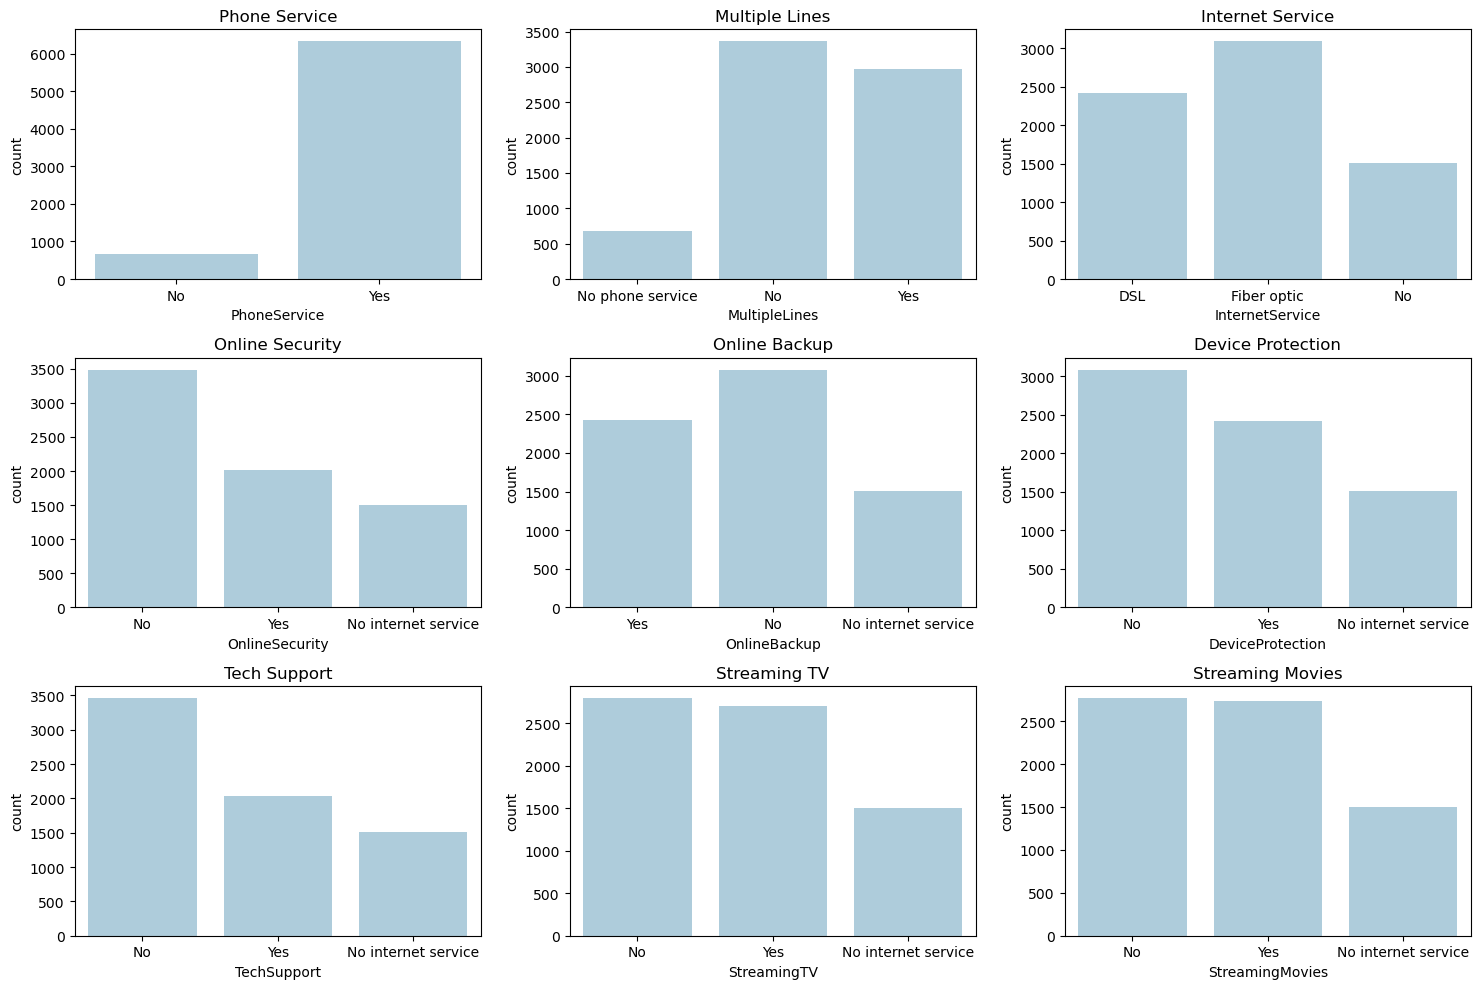

In [15]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
#phone service
sns.countplot(x = df['PhoneService'], ax=ax[0,0]).set_title('Phone Service')
ax[0,0].set_title('Phone Service')
#Multiple Lines
sns.countplot(x = df['MultipleLines'], ax=ax[0,1]).set_title('Multiple Lines')
ax[0,1].set_title('Multiple Lines')
#Internet Service
sns.countplot(x = df['InternetService'], ax=ax[0,2]).set_title('Internet Service')
ax[0,2].set_title('Internet Service')
#Online Security
sns.countplot(x = df['OnlineSecurity'], ax=ax[1,0]).set_title('Online Security')
ax[1,0].set_title('Online Security')
#Online Backup
sns.countplot(x = df['OnlineBackup'], ax=ax[1,1]).set_title('Online Backup')
ax[1,1].set_title('Online Backup')
#Device Protection
sns.countplot(x = df['DeviceProtection'], ax=ax[1,2]).set_title('Device Protection')
ax[1,2].set_title('Device Protection')
#Tech Support
sns.countplot(x = df['TechSupport'], ax=ax[2,0]).set_title('Tech Support')
ax[2,0].set_title('Tech Support')
#Streaming TV
sns.countplot(x = df['StreamingTV'], ax=ax[2,1]).set_title('Streaming TV')
ax[2,1].set_title('Streaming TV')
#Streaming Movies
sns.countplot(x = df['StreamingMovies'], ax=ax[2,2]).set_title('Streaming Movies')
ax[2,2].set_title('Streaming Movies')

plt.tight_layout()
plt.show()

The plots above show the distribution of different services used by customers:

- **Phone Service:** Most customers have phone service.
- **Multiple Lines:** Among those with phone service, there are more customers with single lines than multiple lines.
- **Internet Service:** Customers are fairly split between DSL and Fiber optic internet service, with a significant number having no internet service.
- **Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, and Streaming Movies:** For these services, a large proportion of customers do not subscribe to them. Among those who do have internet service, the distribution between having the service and not having it varies.

## Tenure and Contract

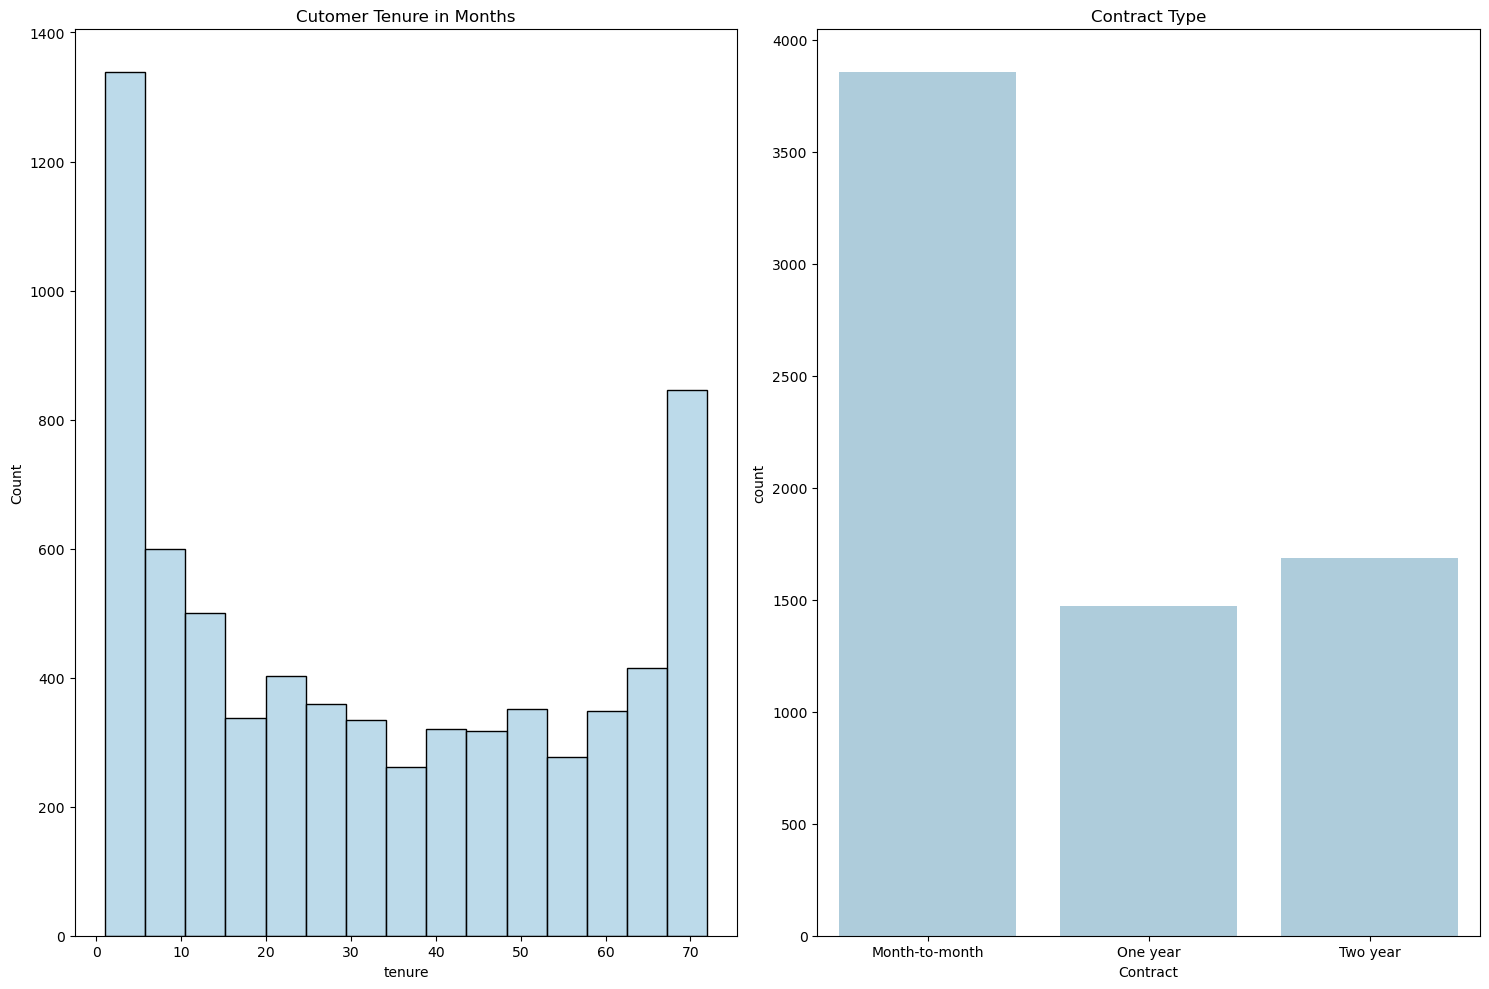

In [16]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
sns.histplot(x = 'tenure', data = df, ax= ax[0]).set_title('Cutomer Tenure in Months')
sns.countplot(x = 'Contract', data = df, ax= ax[1]).set_title('Contract Type')
plt.tight_layout()
plt.show()

The plots above show the distribution of customer tenure and contract types:

- **Customer Tenure in Months:** The histogram shows the distribution of how long customers have been with the company. There is a peak at the beginning (new customers) and another peak at the end (long-term customers), with fewer customers in the middle range of tenure.
- **Contract Type:** The bar plot indicates that the majority of customers have month-to-month contracts, followed by two-year contracts, and then one-year contracts. This suggests a preference for shorter, more flexible contracts.

## Billing and Charges

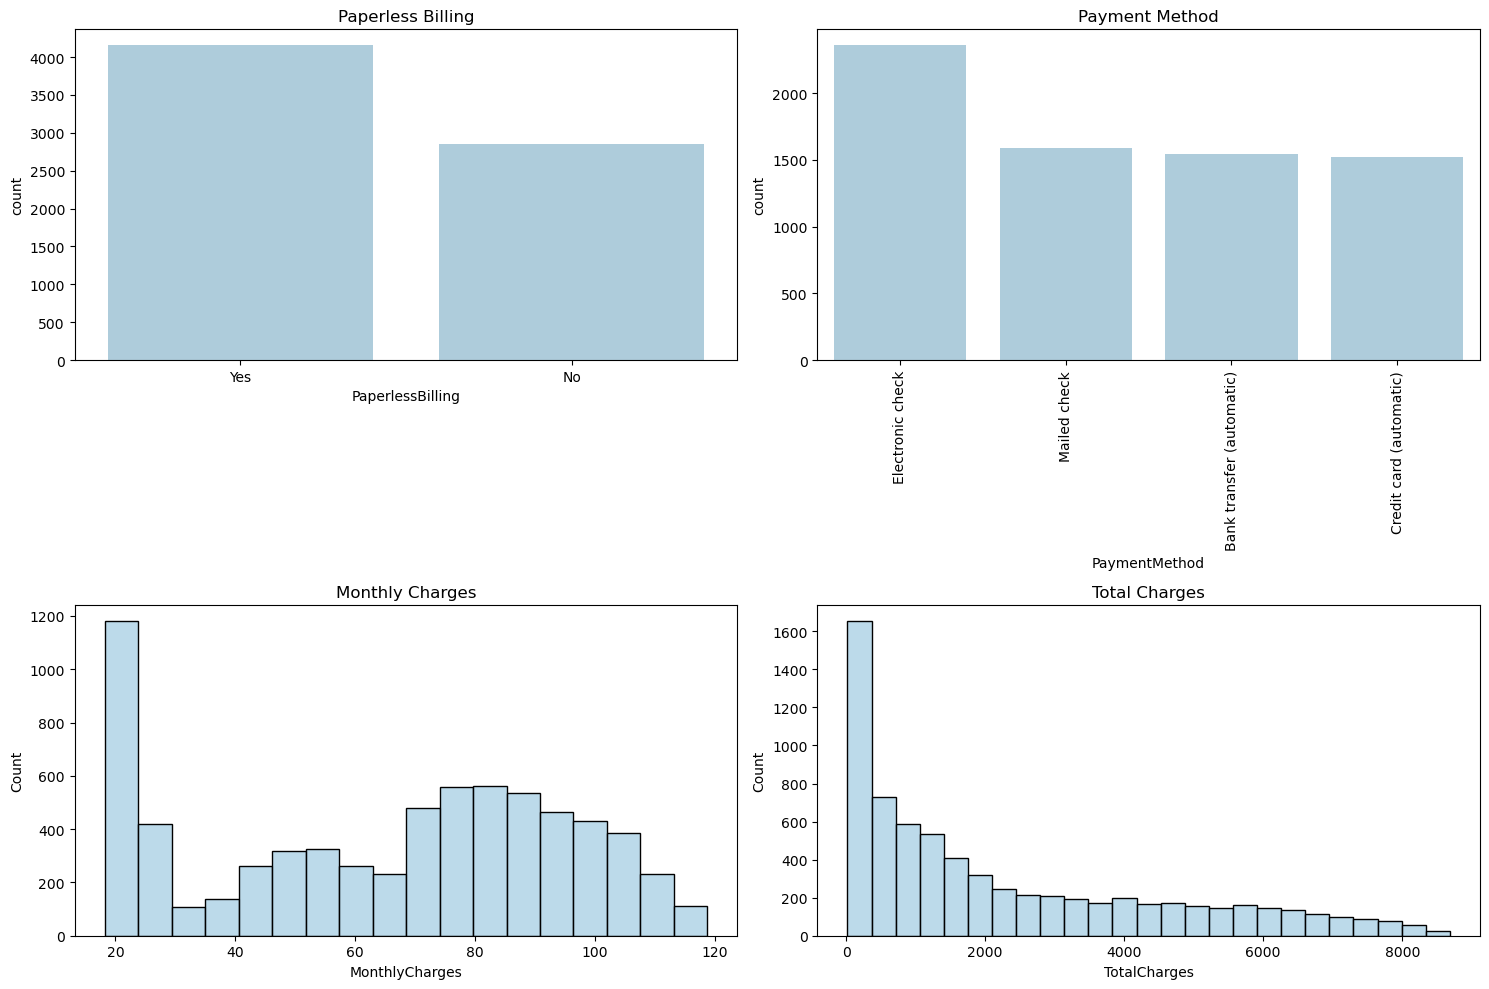

In [17]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#Paperless Billing
sns.countplot(x = df['PaperlessBilling'], ax=ax[0,0]).set_title('Paperless Billing')

#Payment Method
sns.countplot(x = df['PaymentMethod'], ax=ax[0,1]).set_title('Payment Method')
ax[0,1].xaxis.set_tick_params(rotation=90)

#Monthly Charges
sns.histplot(x = 'MonthlyCharges', data = df, ax = ax[1,0]).set_title('Monthly Charges')

#Total Charges
sns.histplot(x = 'TotalCharges', data = df, ax = ax[1,1]).set_title('Total Charges')

plt.tight_layout()
plt.show()

The plots above show the distribution of billing and charges related information:

- **Paperless Billing:** A larger number of customers use paperless billing compared to those who receive paper bills.
- **Payment Method:** Electronic check is the most popular payment method, followed by Mailed check, Bank transfer (automatic), and Credit card (automatic).
- **Monthly Charges:** The histogram shows a wide distribution of monthly charges, with peaks at lower and higher values, and a dip in the middle.
- **Total Charges:** The histogram for total charges is right-skewed, indicating that most customers have lower total charges, with a few customers having very high total charges. This is likely related to customer tenure.

## Churn Count Distribution

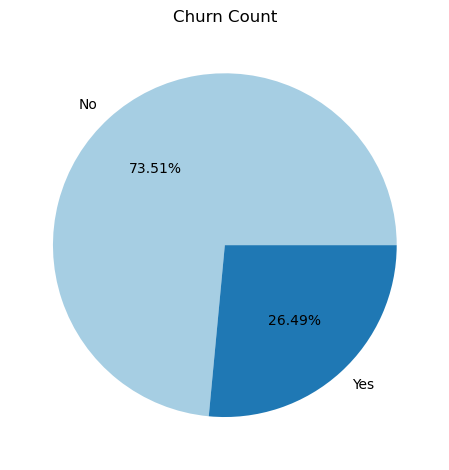

In [18]:
sns.set_palette('Paired')  # Color Palette
plt.pie(x = df['Churn'].value_counts(), labels = df['Churn'].unique(), autopct = '%1.2f%%')
plt.title('Churn Count')

plt.tight_layout()
plt.show()

While the majority of customers haven't churned, a churn rate of over 26% is still significant. This indicates that there's a substantial portion of customers leaving the company, which suggests there is room for improvement.

# Bivariate Analysis.

## Customer Demographics and Churn

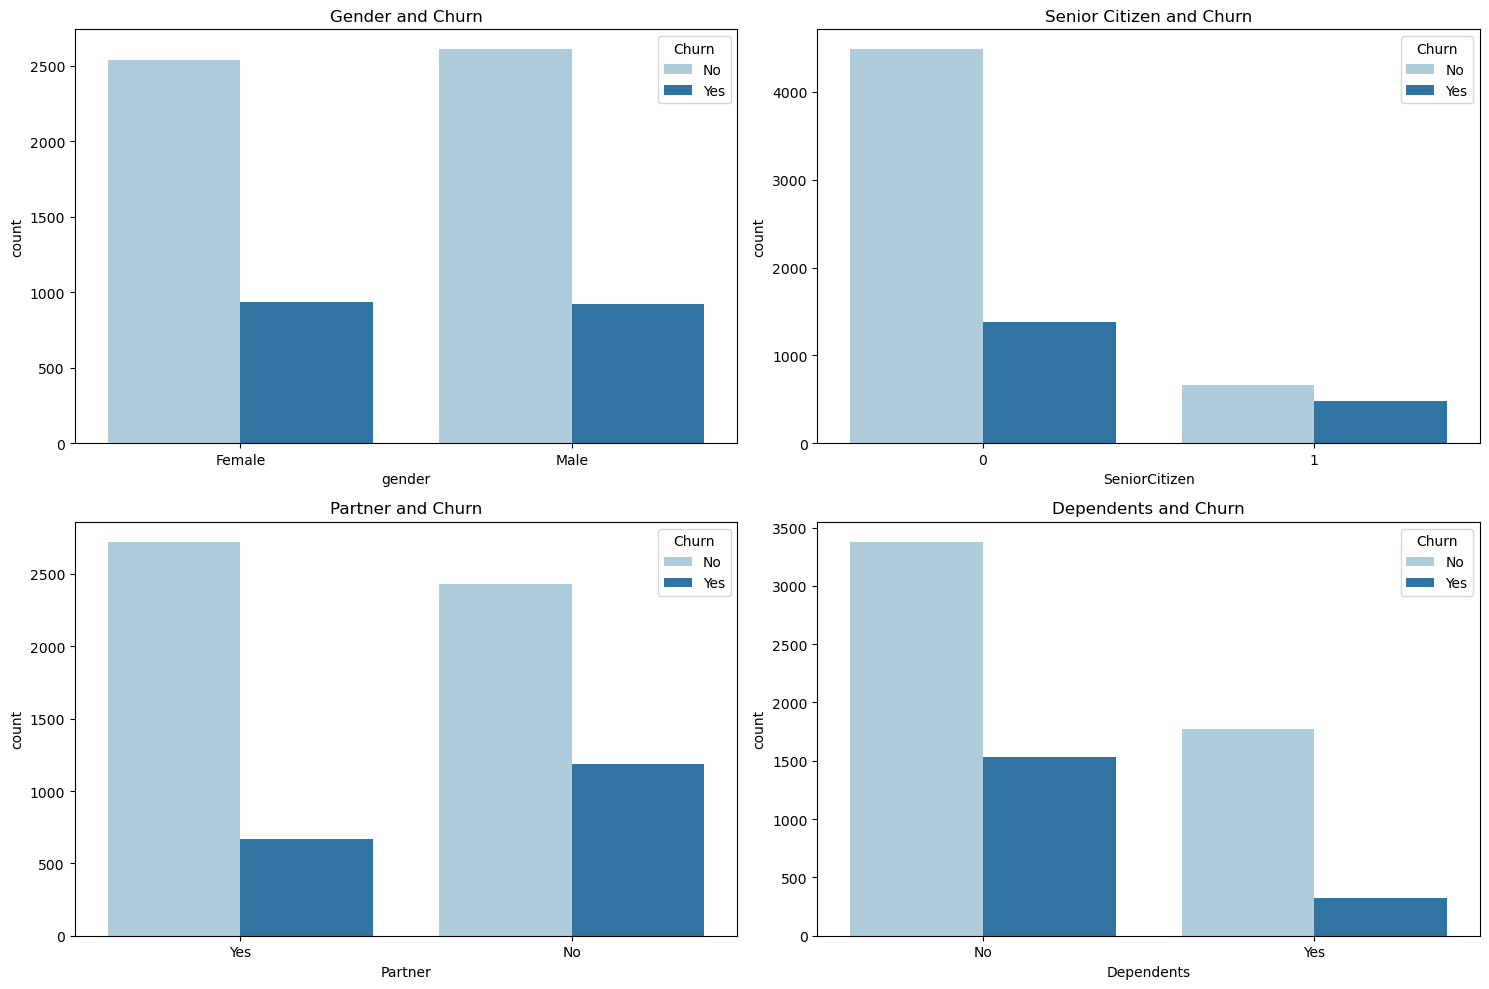

In [19]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#Gender Distribution
sns.countplot(x = 'gender', data = df, hue = 'Churn', ax=ax[0,0])
ax[0,0].set_title('Gender and Churn')

#Senior Citizen Distribution
sns.countplot(x = df['SeniorCitizen'], ax=ax[0,1], hue = df['Churn']).set_title('Senior Citizen and Churn')

#Partner Distribution
sns.countplot( x = df['Partner'], ax=ax[1,0], hue = df['Churn']).set_title('Partner and Churn')

#Dependents Distribution
sns.countplot(x = df['Dependents'], ax=ax[1,1], hue = df['Churn']).set_title('Dependents and Churn')

plt.tight_layout()
plt.show()

Based on the plots of customer demographics and churn:

- **Gender:** There is no significant difference in churn rate between male and female customers.
- **Senior Citizen:** Senior citizens have a higher churn rate compared to non-senior citizens.
- **Partner:** Customers with partners have a lower churn rate than those without partners.
- **Dependents:** Customers with dependents have a lower churn rate than those without dependents.

These observations suggest that senior citizens and customers without partners or dependents are more likely to churn.

## Services and Churn

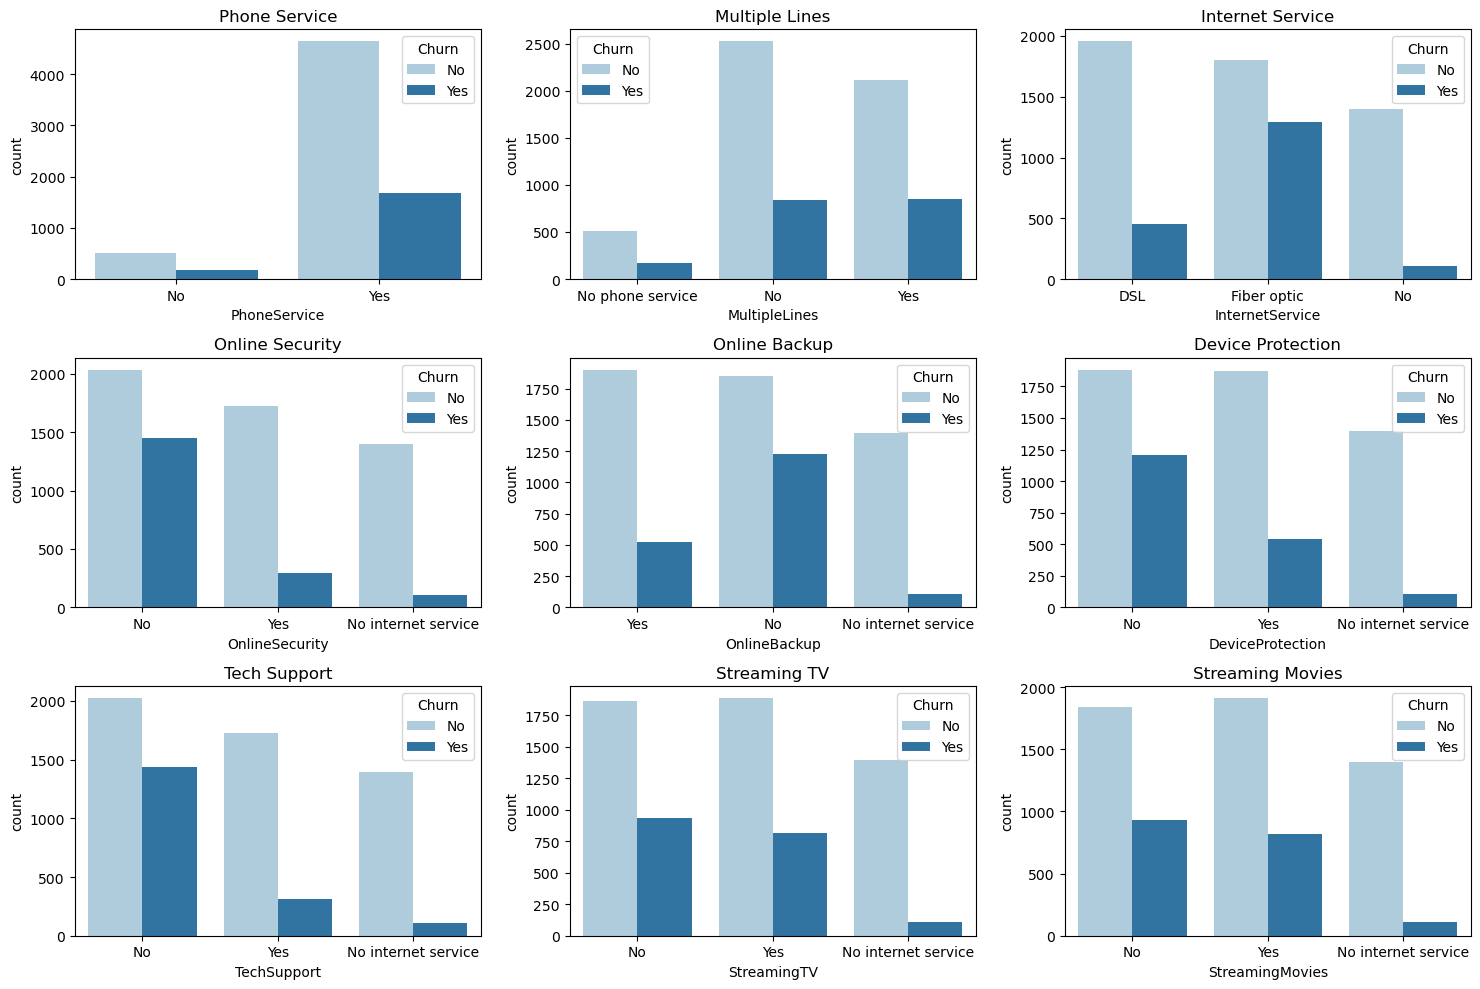

In [20]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
#phone service
sns.countplot(x = df['PhoneService'], ax=ax[0,0], hue = df['Churn']).set_title('Phone Service')
ax[0,0].set_title('Phone Service')
#Multiple Lines
sns.countplot(x = df['MultipleLines'], ax=ax[0,1], hue = df['Churn']).set_title('Multiple Lines')
ax[0,1].set_title('Multiple Lines')
#Internet Service
sns.countplot(x = df['InternetService'], ax=ax[0,2], hue = df['Churn']).set_title('Internet Service')
ax[0,2].set_title('Internet Service')
#Online Security
sns.countplot(x = df['OnlineSecurity'], ax=ax[1,0], hue = df['Churn']).set_title('Online Security')
ax[1,0].set_title('Online Security')
#Online Backup
sns.countplot(x = df['OnlineBackup'], ax=ax[1,1], hue = df['Churn']).set_title('Online Backup')
ax[1,1].set_title('Online Backup')
#Device Protection
sns.countplot(x = df['DeviceProtection'], ax=ax[1,2], hue = df['Churn']).set_title('Device Protection')
ax[1,2].set_title('Device Protection')
#Tech Support
sns.countplot(x = df['TechSupport'], ax=ax[2,0], hue = df['Churn']).set_title('Tech Support')
ax[2,0].set_title('Tech Support')
#Streaming TV
sns.countplot(x = df['StreamingTV'], ax=ax[2,1], hue = df['Churn']).set_title('Streaming TV')
ax[2,1].set_title('Streaming TV')
#Streaming Movies
sns.countplot(x = df['StreamingMovies'], ax=ax[2,2], hue = df['Churn']).set_title('Streaming Movies')
ax[2,2].set_title('Streaming Movies')

plt.tight_layout()
plt.show()

Based on the plots of services and churn:

- **Phone Service:** Customers with phone service have a lower churn rate than those without phone service.
- **Multiple Lines:** Among customers with phone service, those with multiple lines have a slightly higher churn rate than those with a single line.
- **Internet Service:** Customers with Fiber optic internet service have a significantly higher churn rate compared to those with DSL or no internet service.
- **Online Security, Online Backup, Device Protection, and Tech Support:** Customers who subscribe to these security and support related services have lower churn rates than those who do not.
- **Streaming TV and Streaming Movies:** Customers who subscribe to streaming services have a slightly higher churn rate than those who do not.

## Tenure and Churn, Contract and Churn

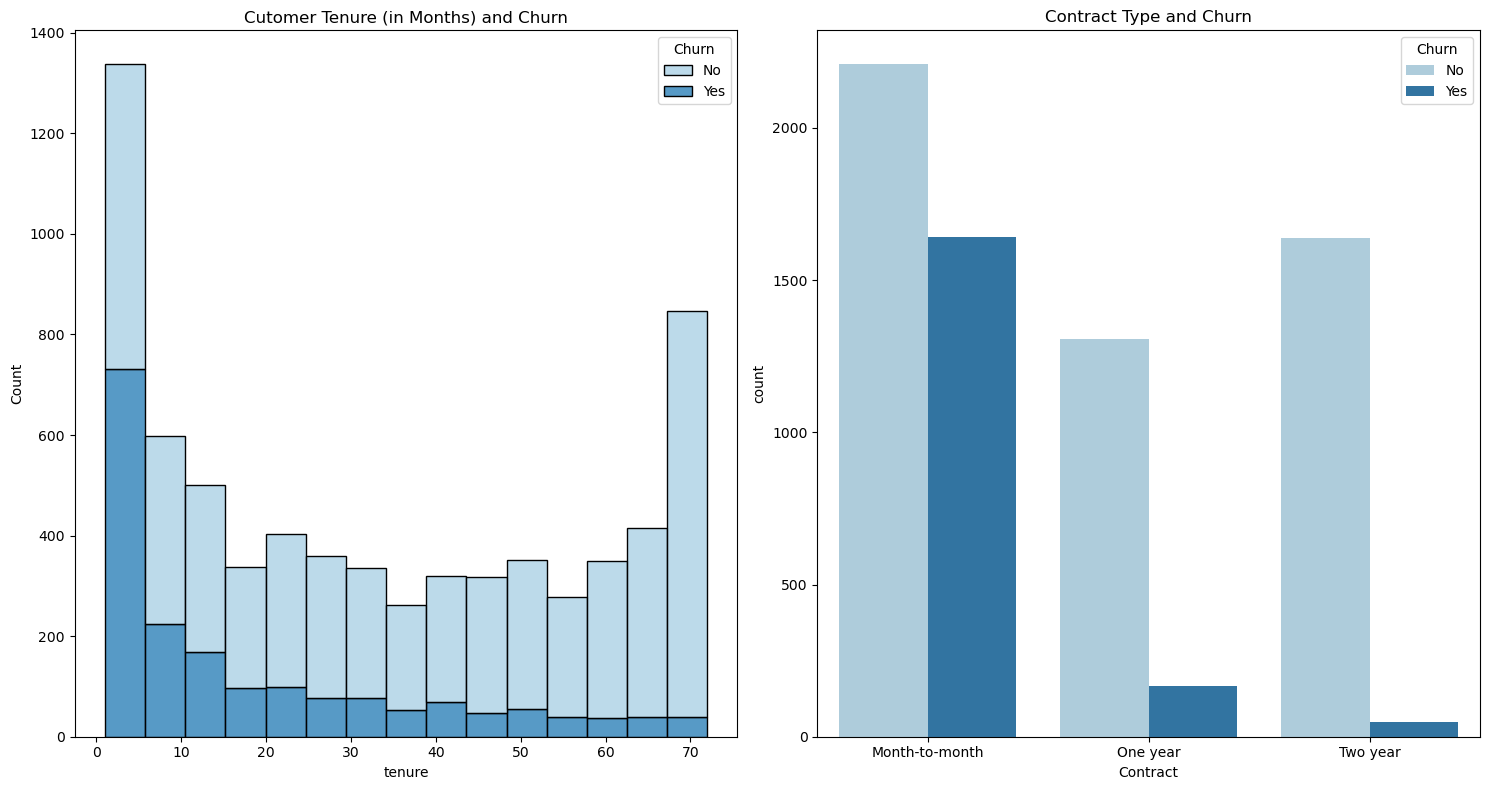

In [21]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
sns.histplot(x = 'tenure', data = df, ax= ax[0], hue = 'Churn', multiple = 'stack').set_title('Cutomer Tenure (in Months) and Churn')
sns.countplot(x = 'Contract', data = df, ax= ax[1], hue = 'Churn').set_title('Contract Type and Churn')
plt.tight_layout()
plt.show()

Based on the plots of tenure and contract type with respect to churn:

- **Tenure and Churn:** The histogram shows that customers with shorter tenure have a higher churn rate compared to customers with longer tenure.
- **Contract Type and Churn:** Customers with month-to-month contracts have a significantly higher churn rate than those with one-year or two-year contracts. Customers with two-year contracts have the lowest churn rate.

These observations suggest that newer customers and those with more flexible, short-term contracts are more likely to churn.

## Billing and Churn, Charges and Churn

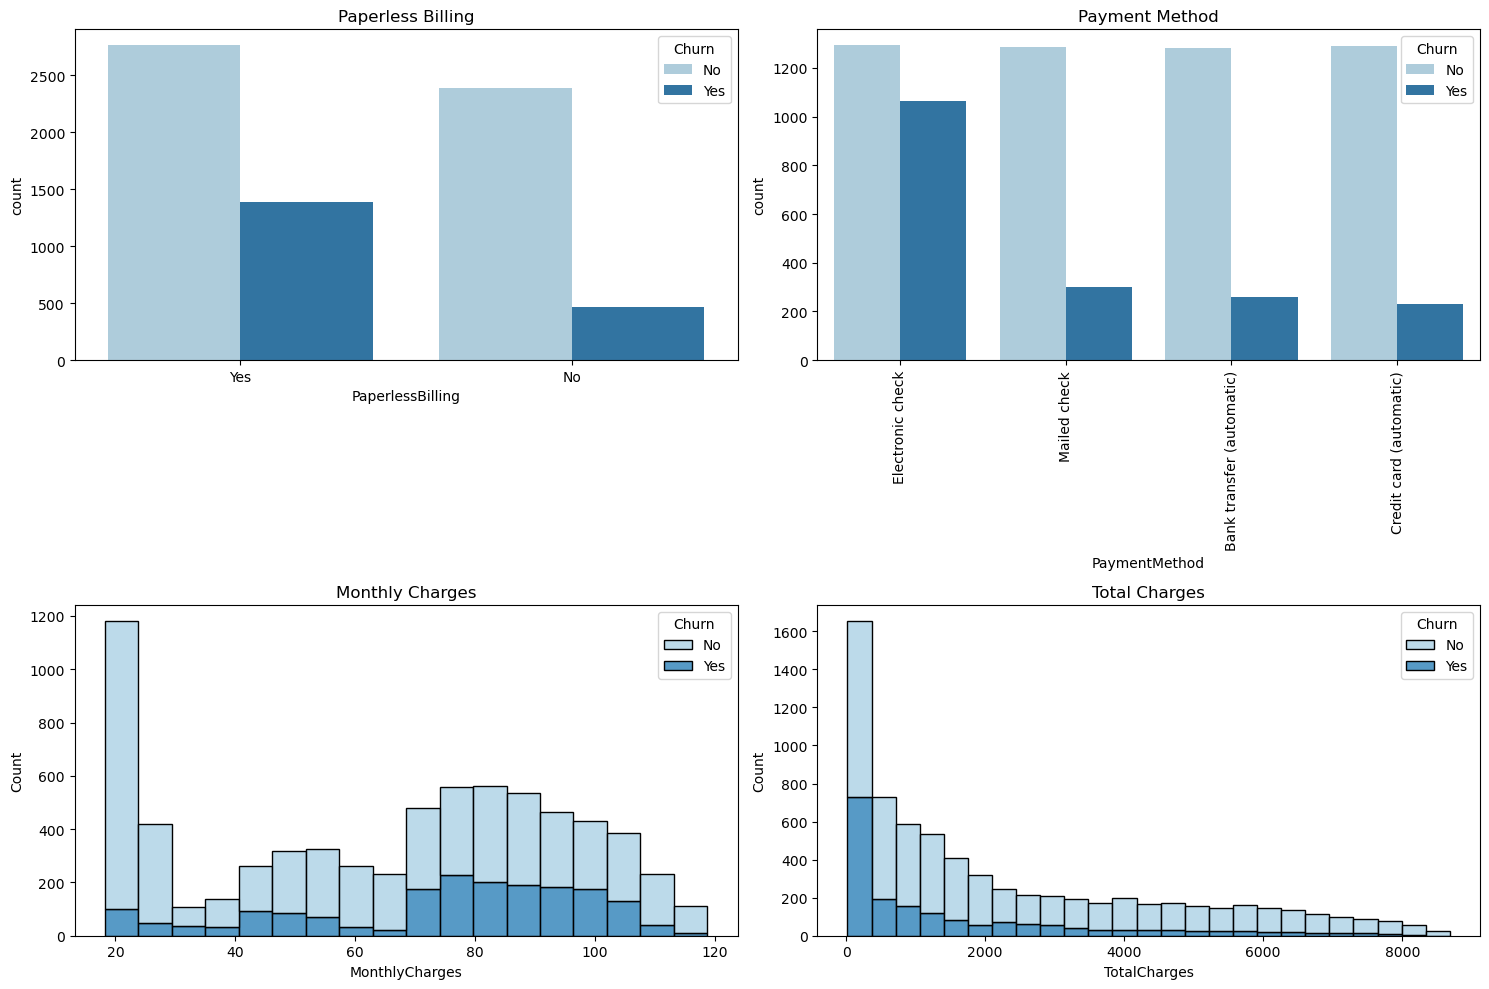

In [22]:
sns.set_palette('Paired')  # Color Palette
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=5.0)

#spacing between subplots
fig.subplots_adjust(hspace=0.9)


#papaerless billing
sns.countplot(x = df['PaperlessBilling'], ax=ax[0,0], hue = df['Churn']).set_title('Paperless Billing')

#Payment Method
sns.countplot(x = df['PaymentMethod'], ax=ax[0,1], hue = df['Churn']).set_title('Payment Method')
ax[0,1].xaxis.set_tick_params(rotation=90)

#Monthly Charges
sns.histplot(x = 'MonthlyCharges', data = df, ax = ax[1,0], hue = 'Churn', multiple= 'stack').set_title('Monthly Charges')

#Total Charges
sns.histplot(x = 'TotalCharges', data = df, ax = ax[1,1], hue = 'Churn', multiple= 'stack').set_title('Total Charges')

plt.tight_layout()
plt.show()

Based on the plots of billing and charges with respect to churn:

- **Paperless Billing:** Customers with paperless billing have a higher churn rate than those with paper bills.
- **Payment Method:** Customers using Electronic check payment method have a significantly higher churn rate than those using other payment methods.
- **Monthly Charges:** Customers with higher monthly charges have a higher churn rate.
- **Total Charges:** Customers with lower total charges have a higher churn rate. This aligns with the observation that newer customers with shorter tenure (and thus lower total charges) are more likely to churn.

# Data Preprocessing Part 2

## Outlier

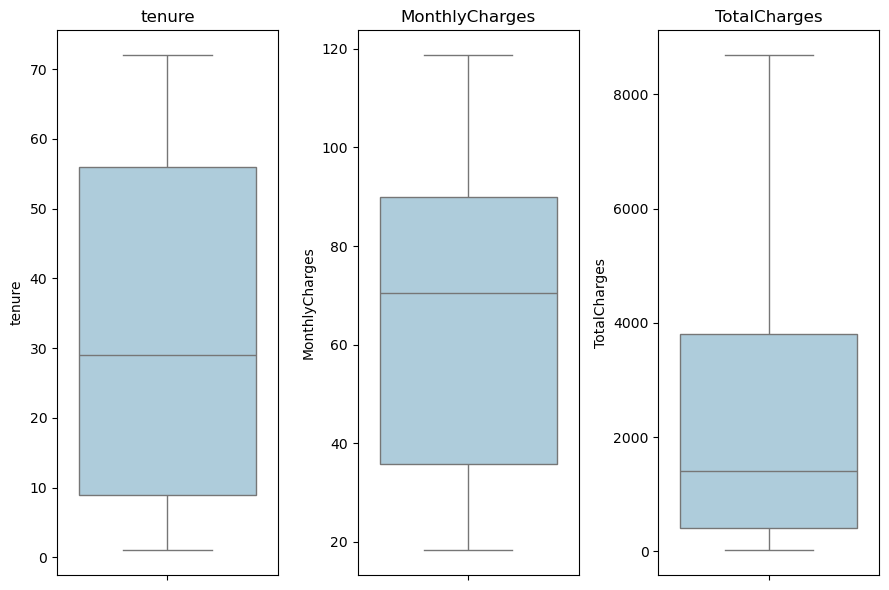

In [23]:
# Check for outlier
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [24]:
# Remove outlier using IQR
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Label Encoding

In [25]:
# Label Encode Object
le = LabelEncoder()

# Columns to encode (object type)
cols_to_encode = df.select_dtypes(include='object').columns

# Label encoding the  columns
for col in cols_to_encode:
  df[col] = le.fit_transform(df[col])

#checking the unique values in each column
cols = df.columns
for i in cols:
    print(i, df[i].unique(), '\n')

gender [0 1] 

SeniorCitizen [0 1] 

Partner [1 0] 

Dependents [0 1] 

tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] 

PhoneService [0 1] 

MultipleLines [1 0 2] 

InternetService [0 1 2] 

OnlineSecurity [0 2 1] 

OnlineBackup [2 0 1] 

DeviceProtection [0 2 1] 

TechSupport [0 2 1] 

StreamingTV [0 2 1] 

StreamingMovies [0 2 1] 

Contract [0 1 2] 

PaperlessBilling [1 0] 

PaymentMethod [2 3 0 1] 

MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ] 

TotalCharges [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] 

Churn [0 1] 



## Feature Scaling

In [26]:
#Standardizing the data
sc = StandardScaler()
df[['tenure', 'MonthlyCharges', 'TotalCharges']] = sc.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [27]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.285566,0,1,0,0,2,0,0,0,0,0,1,2,-1.165523,-0.997284,0
1,1,0,0,0,0.060346,1,0,0,2,0,2,0,0,0,1,0,3,-0.264071,-0.176848,0
2,1,0,0,0,-1.244781,1,0,0,2,2,0,0,0,0,0,1,3,-0.367189,-0.962740,1
3,1,0,0,0,0.508983,0,1,0,2,0,2,2,0,0,1,0,0,-0.751387,-0.198355,0
4,0,0,0,0,-1.244781,1,0,1,0,0,0,0,0,0,0,1,2,0.193308,-0.943549,1


## Correlation Matrix Heatmap

<Axes: >

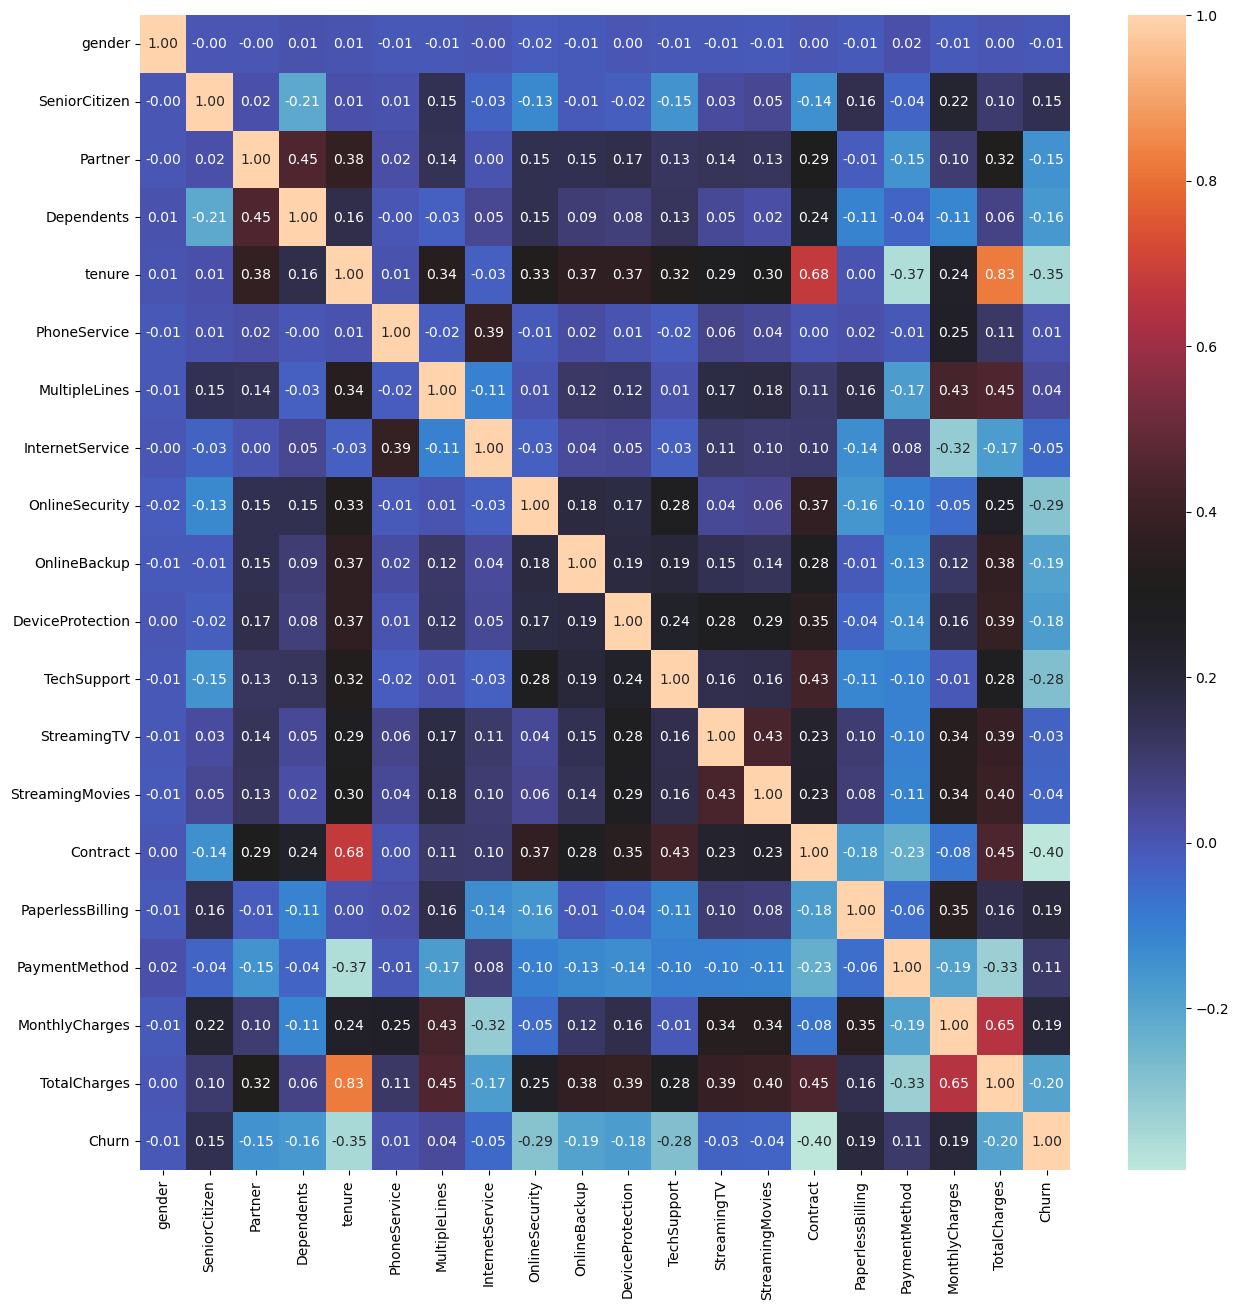

In [28]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='icefire', fmt=".2f")

Based on the correlation heatmap:

- **Churn and Tenure:** There is a moderate negative correlation (-0.35) between Churn and Tenure, indicating that customers with longer tenure are less likely to churn.
- **Churn and Contract:** There is a strong negative correlation (-0.40) between Churn and Contract type, indicating that customers with longer contract terms (One year and Two year) are less likely to churn compared to those with Month-to-month contracts.
- **Churn and InternetService (Fiber optic):** There is a positive correlation (0.31) between Churn and Fiber optic internet service, suggesting that customers with Fiber optic internet are more likely to churn.
- **Churn and Monthly Charges:** There is a moderate positive correlation (0.19) between Churn and Monthly Charges, indicating that customers with higher monthly charges are slightly more likely to churn.
- **Churn and Total Charges:** There is a moderate negative correlation (-0.20) between Churn and Total Charges, which aligns with the relationship between Churn and Tenure.
- **Services and Churn:** Services like Online Security, Tech Support, Online Backup, and Device Protection show negative correlations with Churn, suggesting that customers who subscribe to these services are less likely to churn.
- **Tenure and Total Charges:** There is a strong positive correlation (0.83) between Tenure and Total Charges, which is expected as customers who stay longer will have accumulated higher total charges.

Overall, the heatmap reinforces the insights gained from the individual plots, highlighting key factors associated with customer churn, such as tenure, contract type, internet service type, and subscription to security and support services.

# Train Test Split

In [29]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Churn'), df['Churn'], test_size=0.2, random_state=42)

## Model Building

Following models to predict the customer churn:

1.   Logistic Regression Classifier
2.   Support Vector Machine (SVM) Classifier
3.   Naive Bayes Classifier

### Logistic Regression

In [30]:
# Logistic Regression Classifier Object with standard parameters
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Training the model
log_reg.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_l = duration.total_seconds()
minutes = int(total_seconds_l // 60)
seconds = int(total_seconds_l % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Predicting the values
y_pred = log_reg.predict(X_test)

[INFO] started at 19:46:04
[INFO] ended at 19:46:04
[INFO] Duration: 0 min 0 seconds


Test Accuracy: 0.8217

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1081
           1       0.62      0.57      0.60       321

    accuracy                           0.82      1402
   macro avg       0.75      0.73      0.74      1402
weighted avg       0.82      0.82      0.82      1402



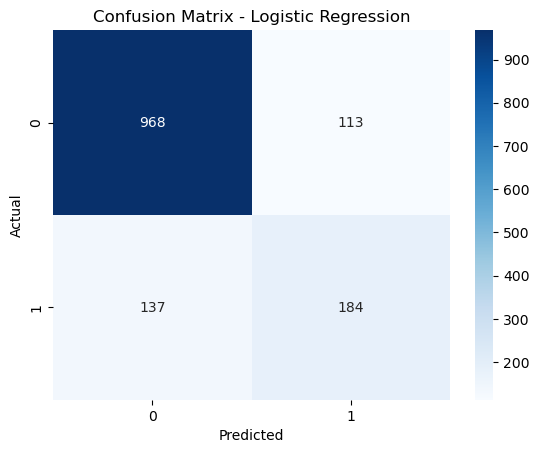

ROC-AUC Score: 0.8511


In [31]:
# Test accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC-AUC
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

### Support Vector Machine (SVM) Classifier

In [32]:
# SVM Classifier Object
svm = SVC()

### Hyperparameter Tuning using RandomizedSearchCV

In [33]:
# Parameter distribution
param_dist = {
    'C': loguniform(0.1, 100),
    'gamma': loguniform(0.001, 1),
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Randomized Search Object
random_search = RandomizedSearchCV(
    estimator = svm,
    param_distributions = param_dist,
    n_iter = 25,
    cv = 3,
    n_jobs = -1,
    verbose = 2,
    scoring = 'roc_auc',
    random_state = 42
)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Train model
random_search.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds = duration.total_seconds()
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Best parameters
print(random_search.best_params_)

[INFO] started at 19:46:04
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[INFO] ended at 19:49:04
[INFO] Duration: 2 min 59 seconds
{'C': np.float64(1.4656553886225332), 'gamma': np.float64(0.006516990611177174), 'kernel': 'rbf'}


In [34]:
#SVM Classifier Object with best parameters
svm  = SVC(kernel='rbf', C=1.4656553886225332, gamma=0.006516990611177174, probability=True, random_state = 42)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Training the model
svm.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_svm = duration.total_seconds()
minutes = int(total_seconds_svm // 60)
seconds = int(total_seconds_svm % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

#Training accuracy
print('Training Accuracy: ', svm.score(X_train, y_train))

#Predicting the values
y_pred_svm = svm.predict(X_test)

[INFO] started at 19:49:04
[INFO] ended at 19:49:07
[INFO] Duration: 0 min 3 seconds
Training Accuracy:  0.7949358059914408


Test Accuracy (RSVM): 0.8260

Classification Report (RSVM):
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1081
           1       0.66      0.50      0.57       321

    accuracy                           0.83      1402
   macro avg       0.76      0.71      0.73      1402
weighted avg       0.82      0.83      0.82      1402



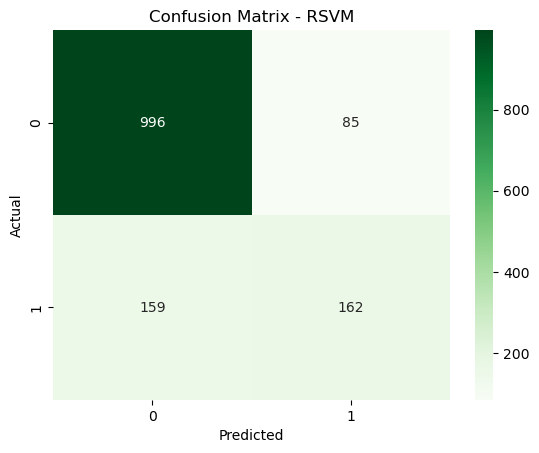

ROC-AUC Score (RSVM): 0.8424


In [35]:
# Test accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'Test Accuracy (RSVM): {acc_svm:.4f}')

# Classification report
print("\nClassification Report (RSVM):")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - RSVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f'ROC-AUC Score (RSVM): {roc_auc_svm:.4f}')

### Fine-tuning using GridSearchCV

In [36]:
# Parameter distribution
param_dist_search = {
    'C': [0.8, 1.0, 1.2, 1.5, 1.8],
    'gamma': [0.004, 0.005, 0.0065, 0.008, 0.01],
    'kernel' : ['rbf']
}

# Grid Search Object
grid_search = GridSearchCV(
    estimator = svm,
    param_grid = param_dist_search,
    cv = 5,
    n_jobs = -1,
    verbose = 2,
    scoring = 'roc_auc'
)
# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Fitting the data
grid_search.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds = duration.total_seconds()
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Best parameters
print(grid_search.best_params_)

[INFO] started at 19:49:09
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[INFO] ended at 19:50:25
[INFO] Duration: 1 min 15 seconds
{'C': 1.5, 'gamma': 0.005, 'kernel': 'rbf'}


In [37]:
#SVM Classifier Object with best parameters
svm = SVC(kernel='rbf', C=1.5, gamma=0.005, probability=True, random_state = 42)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Train the model
svm.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_svm2 = duration.total_seconds()
minutes = int(total_seconds_svm2 // 60)
seconds = int(total_seconds_svm2 % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

#Training accuracy
print('Training Accuracy: ', svm.score(X_train, y_train))

#Predicting the values
y_pred_svm = svm.predict(X_test)

[INFO] started at 19:50:25
[INFO] ended at 19:50:28
[INFO] Duration: 0 min 3 seconds
Training Accuracy:  0.795114122681883


Test Accuracy (RSVM): 0.8302

Classification Report (RSVM):
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1081
           1       0.66      0.53      0.59       321

    accuracy                           0.83      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.82      0.83      0.82      1402



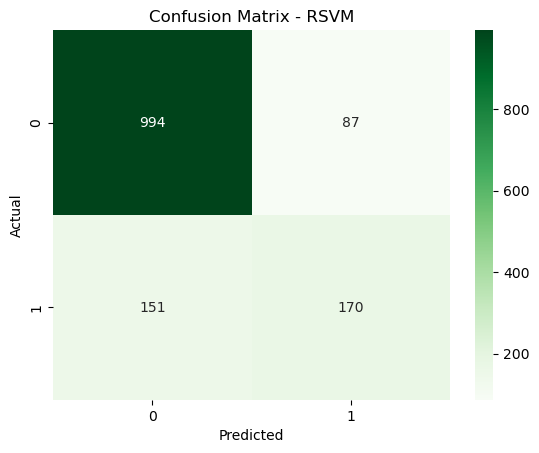

ROC-AUC Score (RSVM): 0.8438


In [38]:
# Test accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'Test Accuracy (RSVM): {acc_svm:.4f}')

# Classification report
print("\nClassification Report (RSVM):")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - RSVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f'ROC-AUC Score (RSVM): {roc_auc_svm:.4f}')

### Naive Bayes Classifier

In [39]:
# Naive Bayes Classifier Object
gnb = GaussianNB()

In [40]:
# Parameter distribution
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

# Grid Search Object
grid_search = GridSearchCV(estimator=gnb, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Fitting the data
grid_search.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds = duration.total_seconds()
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Best parameters
print(grid_search.best_params_)

[INFO] started at 19:50:30
[INFO] ended at 19:50:31
[INFO] Duration: 0 min 0 seconds
{'var_smoothing': np.float64(0.03511191734215131)}


In [41]:
# Naive Bayes Classifier Object
gnb = GaussianNB(
    var_smoothing = 0.03511191734215131
)

# Start timer
start = datetime.now()
print(f"[INFO] started at {start.strftime('%H:%M:%S')}")

# Train the model
gnb.fit(X_train, y_train)

# End timer
end = datetime.now()
print(f"[INFO] ended at {end.strftime('%H:%M:%S')}")

# Compute duration
duration = end - start
total_seconds_gnb = duration.total_seconds()
minutes = int(total_seconds_gnb // 60)
seconds = int(total_seconds_gnb % 60)

print(f"[INFO] Duration: {minutes} min {seconds} seconds")

# Predicting the values
y_pred_gnb = gnb.predict(X_test)

[INFO] started at 19:50:31
[INFO] ended at 19:50:31
[INFO] Duration: 0 min 0 seconds


Test Accuracy (Naive Bayes): 0.7532

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1081
           1       0.48      0.75      0.58       321

    accuracy                           0.75      1402
   macro avg       0.69      0.75      0.70      1402
weighted avg       0.81      0.75      0.77      1402



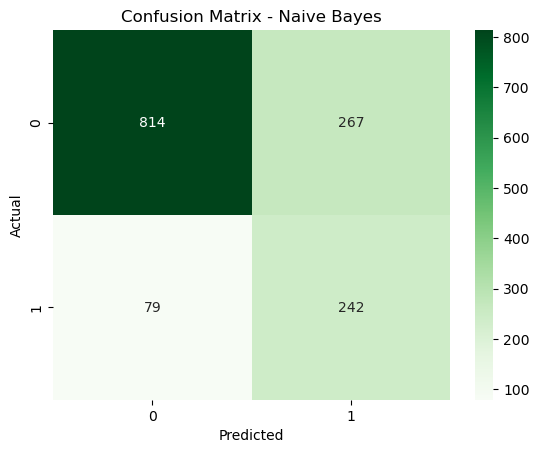

ROC-AUC Score (Rgnb): 0.8257


In [42]:
# Test accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Test Accuracy (Naive Bayes): {acc_gnb:.4f}')

# Classification report
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_gnb))

# Confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
y_pred_proba_gnb = gnb.predict_proba(X_test)[:, 1]
roc_auc_gnb = roc_auc_score(y_test, y_pred_proba_gnb)
print(f'ROC-AUC Score (Rgnb): {roc_auc_gnb:.4f}')

# Model Evaluation

## Confusion Matrix Heatmap

Text(0.5, 1.0, 'Naive Bayes Confusion Matrix')

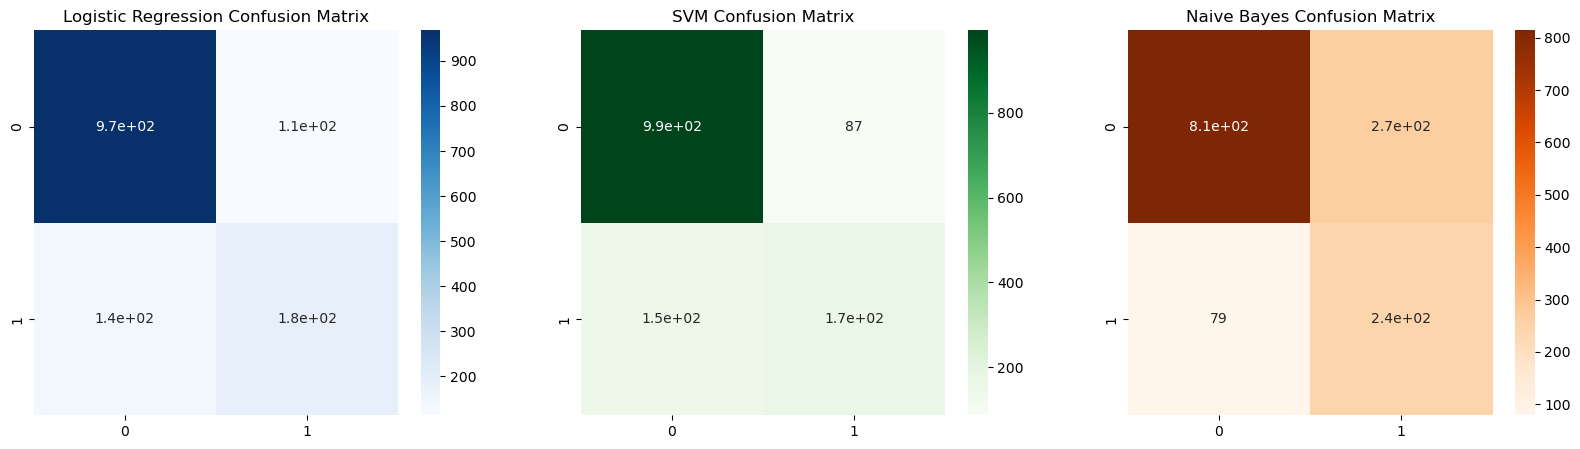

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

#Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, ax=ax[0], cmap='Blues').set_title('Logistic Regression Confusion Matrix')

#SVM Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, ax=ax[1], cmap='Greens').set_title('SVM Confusion Matrix')

#Naive Bayes Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, ax=ax[2], cmap='Oranges').set_title('Naive Bayes Confusion Matrix')

The confusion matrix heatmaps visualize the true positive and true negative predictions for each model. From the comparison, it can be observed that the SVM Classifier achieved the highest number of correctly classified samples, with fewer false positives and false negatives compared to Logistic Regression and Naive Bayes. The Naive Bayes Classifier also performed well, showing strong predictive capability, while Logistic Regression had slightly higher misclassification counts.

Therefore, based on the confusion matrix analysis, the XGBoost Classifier demonstrates the best overall performance in accurately predicting cancer diagnosis, making it the most effective model among the three.

## Probability Distribution Plot

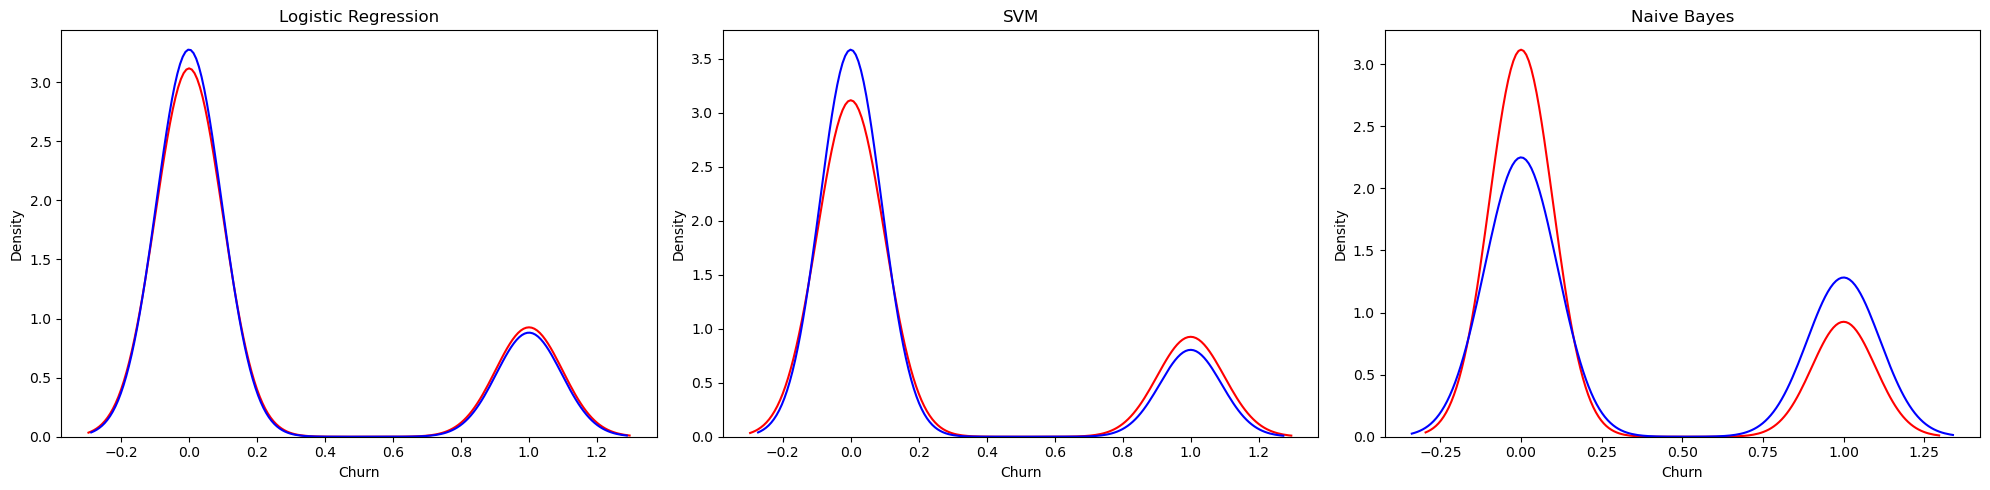

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[0])
sns.kdeplot(y_pred, color="b", label="Fitted Values", ax=ax[0])
ax[0].set_title('Logistic Regression')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Density')

# SVM
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[1])
sns.kdeplot(y_pred_svm, color="b", label="Fitted Values", ax=ax[1])
ax[1].set_title('SVM')
ax[1].set_xlabel('Churn')
ax[1].set_ylabel('Density')

# Naive Bayes
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[2])
sns.kdeplot(y_pred_gnb, color="b", label="Fitted Values", ax=ax[2])
ax[2].set_title('Naive Bayes')
ax[2].set_xlabel('Churn')
ax[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

The following probability distribution plot shows the distribution of predicted probabilities for each class. Logistic Regression produces a smoother and more distinct separation between classes, indicating well-calibrated probabilities. Meanwhile, the SVM model displays overlapping distributions due to uncalibrated probability estimates, even though its overall classification accuracy is higher.

## Train Time Plot

Logistic Regression: baseline (same as Logistic Regression)
SVM: 253.53× slower than Logistic Regression
Naive Bayes: 3.40× faster than Logistic Regression


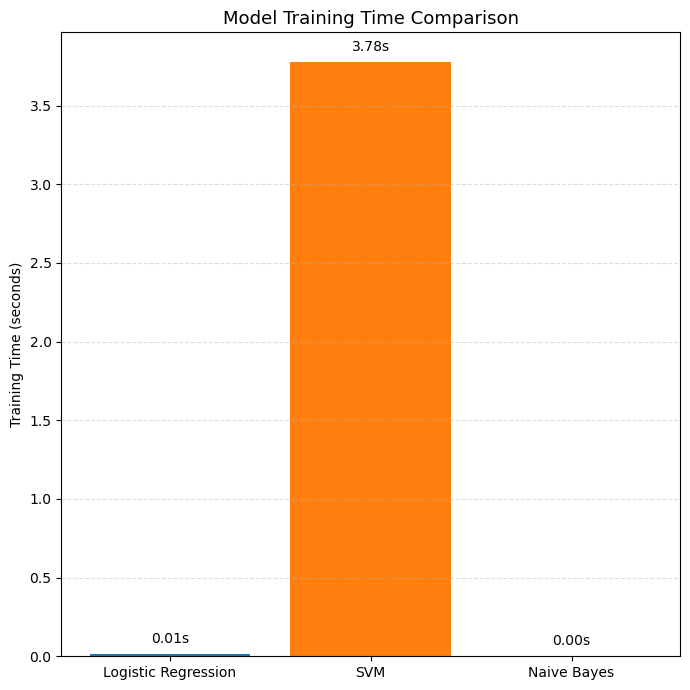

In [ ]:
plt.figure(figsize=(7,7))

models = ['Logistic Regression', 'SVM', 'Naive Bayes']
times = [total_seconds_l, total_seconds_svm2, total_seconds_gnb]

bars = plt.bar(models, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Model Training Time Comparison", fontsize=13)
plt.ylabel("Training Time (seconds)")

# Label each bar with its training time
for bar, time in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, time + 0.05, f"{time:.2f}s", 
             ha='center', va='bottom', fontsize=10)

# Relative training time (time ratio)
baseline = total_seconds_l
ratios = [t / baseline for t in times]

for m, r in zip(models, ratios):
    if r > 1:
        print(f"{m}: {r:.2f}× slower than Logistic Regression")
    elif r < 1:
        print(f"{m}: {1/r:.2f}× faster than Logistic Regression")
    else:
        print(f"{m}: baseline (same as Logistic Regression)")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Classification Report

In [46]:
# Logistic Regression
report_lr = classification_report(y_test, y_pred, output_dict=True)
df_lr = pd.DataFrame(report_lr).transpose()

# SVM
report_rf = classification_report(y_test, y_pred_svm, output_dict=True)
df_svm = pd.DataFrame(report_rf).transpose()

# Naive Bayes
report_xgb = classification_report(y_test, y_pred_gnb, output_dict=True)
df_gnb = pd.DataFrame(report_xgb).transpose()

print("Logistic Regression Report")
display(df_lr.round(3))

print("\nSVM Report")
display(df_svm.round(3))

print("\nNaive Bayes Report")
display(df_gnb.round(3))

Logistic Regression Report


,precision,recall,f1-score,support
0,0.876,0.895,0.886,1081.000
1,0.620,0.573,0.595,321.000
accuracy,0.822,0.822,0.822,0.822
macro avg,0.748,0.734,0.741,1402.000
weighted avg,0.817,0.822,0.819,1402.000



SVM Report


,precision,recall,f1-score,support
0,0.868,0.920,0.893,1081.00
1,0.661,0.530,0.588,321.00
accuracy,0.830,0.830,0.830,0.83
macro avg,0.765,0.725,0.741,1402.00
weighted avg,0.821,0.830,0.823,1402.00



Naive Bayes Report


,precision,recall,f1-score,support
0,0.912,0.753,0.825,1081.000
1,0.475,0.754,0.583,321.000
accuracy,0.753,0.753,0.753,0.753
macro avg,0.693,0.753,0.704,1402.000
weighted avg,0.812,0.753,0.769,1402.000


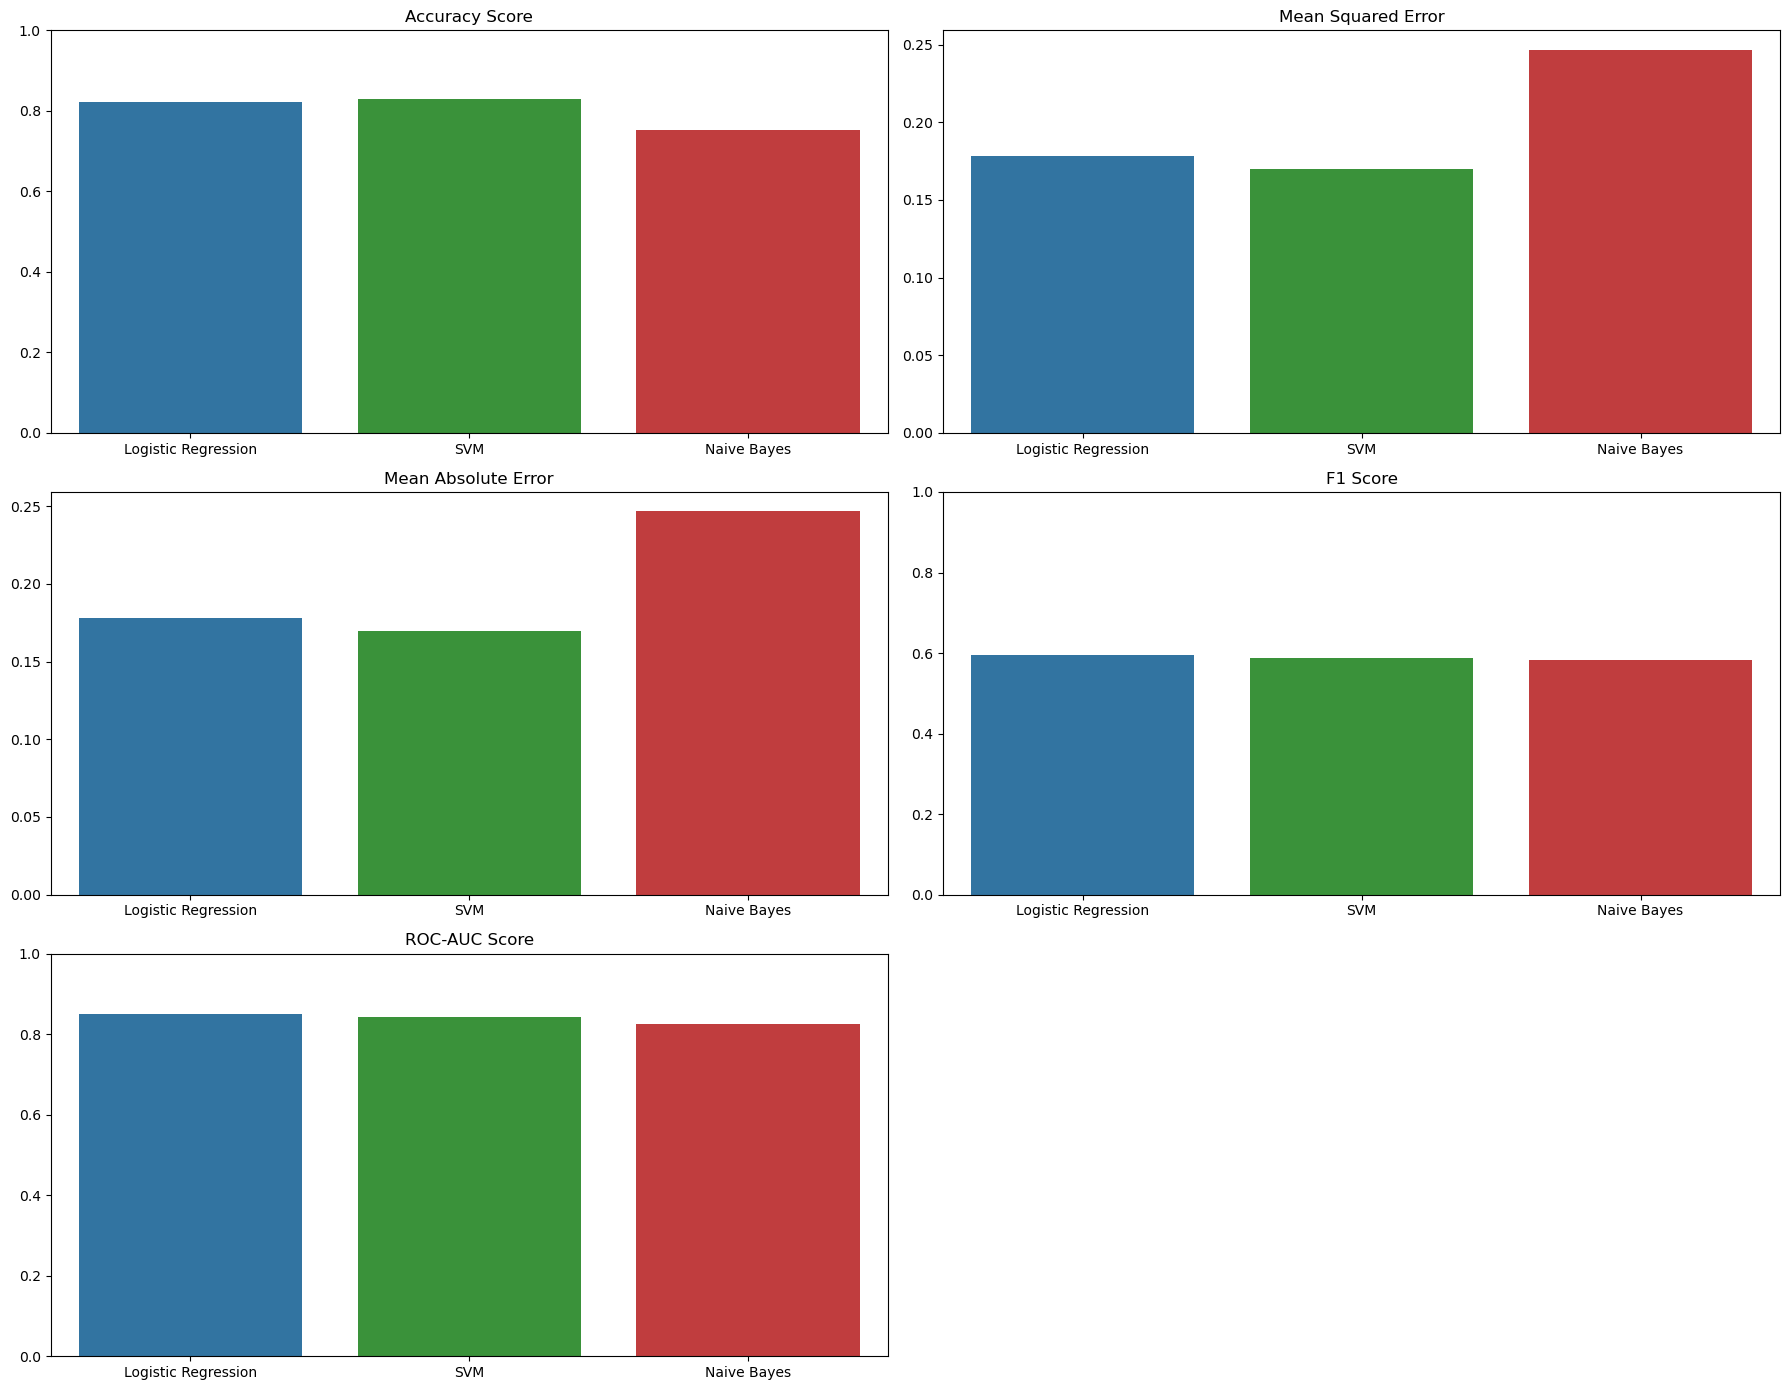

In [47]:
# Bar plots
fig, ax = plt.subplots(3, 2, figsize=(18, 14))

models = ['Logistic Regression', 'SVM', 'Naive Bayes']
palette = ["#1f77b4", "#2ca02c", "#d62728"]

# Accuracy Score
sns.barplot(
    x=models,
    y=[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_gnb)
    ],
    ax=ax[0, 0],
    hue=models,
    palette=palette
)
ax[0, 0].set_title('Accuracy Score')
ax[0, 0].set_ylim(0, 1)

# Mean Squared Error
sns.barplot(
    x=models,
    y=[
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_svm),
        mean_squared_error(y_test, y_pred_gnb)
    ],
    ax=ax[0, 1],
    hue=models,
    palette=palette
)
ax[0, 1].set_title('Mean Squared Error')

# Mean Absolute Error
sns.barplot(
    x=models,
    y=[
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_svm),
        mean_absolute_error(y_test, y_pred_gnb)
    ],
    ax=ax[1, 0],
    hue=models,
    palette=palette
)
ax[1, 0].set_title('Mean Absolute Error')

# F1 Score
sns.barplot(
    x=models,
    y=[
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_gnb)
    ],
    ax=ax[1, 1],
    hue=models,
    palette=palette
)
ax[1, 1].set_title('F1 Score')
ax[1, 1].set_ylim(0, 1)

# ROC-AUC Score
sns.barplot(
    x=models,
    y=[
        roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, gnb.predict_proba(X_test)[:, 1])
    ],
    ax=ax[2, 0],
    hue=models,
    palette=palette
)
ax[2, 0].set_title('ROC-AUC Score')
ax[2, 0].set_ylim(0, 1)

ax[2, 1].axis('off')

# Layout
plt.tight_layout()
plt.show()

These graphs compares the models based on the metrics such as accuracy score, mean squared error, mean absolute error, f1 score, and ROC-AUC Score. The SVM Classifier has the highest accuracy score and lowest mean squared error, mean absolute error. Therefore, the SVM Classifier is a good fit for predicting the customer churn.

# Conclusion

This project focused on predicting customer churn in a telecommunications company using three classification models: Logistic Regression, Support Vector Machine (SVM), and Naive Bayes. After preprocessing and model training, the evaluation showed that SVM achieved the best performance with an accuracy of 83% and a ROC-AUC score of 0.84, followed by Logistic Regression with 82% accuracy and Naive Bayes with 75%.

Although Logistic Regression produced smoother and more well-calibrated probability distributions, SVM delivered higher classification accuracy because of its ability to form stronger decision boundaries. Naive Bayes, on the other hand, was the fastest to train thanks to its simple probabilistic approach.

In summary, there is a clear trade-off between accuracy, interpretability, and computational efficiency. SVM proved to be the most accurate model, Logistic Regression remained the most interpretable, and Naive Bayes worked best for quick predictions when computational resources are limited.